# Time series
Have a look at the code below using generated temperature as sensor data. A Regressor should be used to forecast temperature.

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

Creation of dataset:

In [15]:
# create synthetic time series of temperature
np.random.seed(42)
n = 500

time = np.arange(n)
amplitude = 20*np.random.choice(np.random.random_sample(size=5), size=n)
signal = np.sin(time * 0.03)*amplitude+np.random.randint(0, 10) # simulate temperature
noise = np.random.normal(0, 0.2, n)

y = signal + noise

df = pd.DataFrame({"y": y})
df.describe()

,y
count,500.000000
mean,4.281441
std,8.706293
min,-16.474090
25%,-1.609992
50%,4.955197
75%,10.326222
max,22.193727


In [16]:
df

,y
0,2.945792
1,3.316512
2,4.260329
3,3.493500
4,4.074926
...,...
495,8.505926
496,5.097104
497,13.271028
498,12.783172


Create features (lag features), feature matrix X and target vector y. 

In [17]:
# create lag features
df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)

df = df.dropna()

X = df[["lag1", "lag2", "lag3"]]
y = df["y"]



Train-test split! Note that instead of a random split, a simple temporal slicing is done!

In [18]:
# time based split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


Train a RF Regressor

In [19]:
# train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# predictions
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 4.611309463625988


<Axes: ylabel='y'>

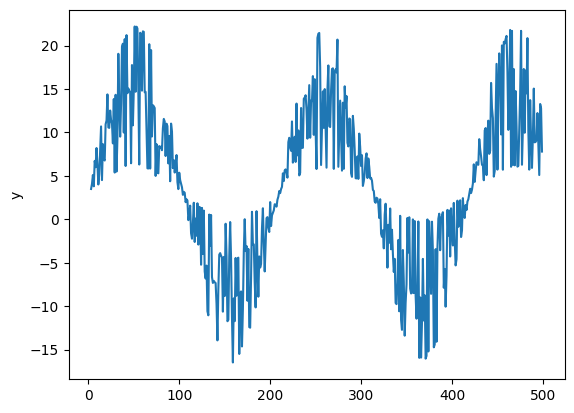

In [20]:
sns.lineplot(df["y"])

<Axes: >

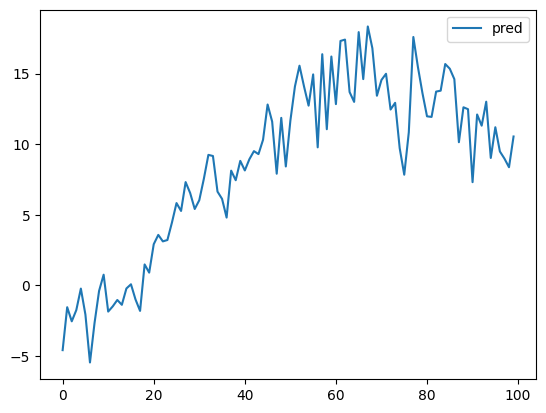

In [21]:
sns.lineplot(preds, label="pred")

Try to improve the accuracy of the Regressor by adding lag features or a rolling mean and rolling standard, play with the window and distances of lag features:

In [22]:
# create lag features
df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3) 


df["rolling_mean_5"] = df["y"].rolling(window=5).mean() # explanation: rolling mean of the last 5 values
df["rolling_std_5"] = df["y"].rolling(window=5).std()

df = df.dropna()

X = df[["lag1", "lag2", "lag3", "rolling_std_5", "rolling_mean_5"]]
y = df["y"]

# time based split
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

C:\Users\Startklar\AppData\Local\Temp\ipykernel_5040\3194635765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lag1"] = df["y"].shift(1)
C:\Users\Startklar\AppData\Local\Temp\ipykernel_5040\3194635765.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lag2"] = df["y"].shift(2)
C:\Users\Startklar\AppData\Local\Temp\ipykernel_5040\3194635765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

You can also try other Models (e.g. GradientBoostingRegressor or LinearRegression) and see how the RMSE behaves...

### Forecasting:

Assume you want to forecast the next three temperature points. There are two different ways to achieve that - recursive or direct. Have a look at the code below and discuss what it achieves:

In [24]:
df = pd.DataFrame({"y": y})

df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)

df["y_t1"] = df["y"].shift(-1)
df["y_t2"] = df["y"].shift(-2)
df["y_t3"] = df["y"].shift(-3)

df = df.dropna()

X = df[["lag1","lag2","lag3"]]

y1 = df["y_t1"]
y2 = df["y_t2"]
y3 = df["y_t3"]

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

model1 = RandomForestRegressor().fit(X_train, y1[:split])
model2 = RandomForestRegressor().fit(X_train, y2[:split])
model3 = RandomForestRegressor().fit(X_train, y3[:split])

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

<Axes: >

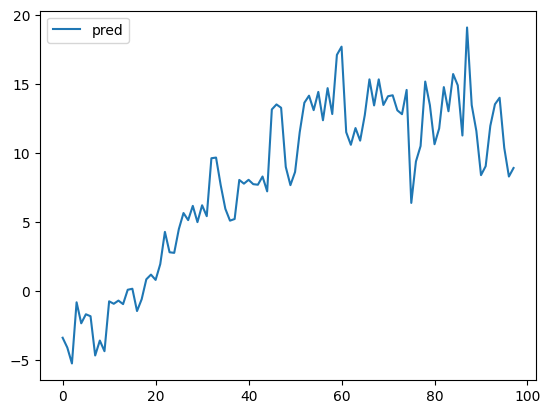

In [28]:
sns.lineplot(pred1, label="pred")